# Overview

A well known issue with piezoelectric pickups for upright bass is the need for an amplifier with a high-impedance input. But how high? My own **HPF-Pre** preamps are all made with 10 $M\Omega$ input impedance. Is that enough? Too much? Many amps come with 1M $\Omega$ impedance. Is it enough?

Some electronic testing might shed some light on this issue.

A *pretty good* electrical model of a piezo pickup is a voltage source $V$ in series with a capacitance $C$. One terminal of the pickup is grounded. The other terminal is connected to the amplifier, which has its own input resistance R. Am I confusing resistance and impedance? Most amplifiers have a purely resistive input, so the resistance equals the impedance.

![Pickup model](img/pickup_model.png)

Like many upright bassists, I have a drawer with pickups that I've tried over the years. Let's pull one out. I measured its capacitance with my multimeter, and it's about 22 nF. The capacitance, combined with R, forms a passive high pass filter, whose -3 dB frequency is:

$f_c = \dfrac 1 {2 \pi R C}$

Here are some different values for the resistance, if the pickup has a 22 nF capacitance.

    | R        | F_c (Hz)  |
    |----------|-----------|
    | 10 M     | 0.72      |
    | 1 M      | 7.2       |
    | 100 k    | 72        |

For this pickup, 100k $\Omega$ might produce a noticeable loss of low frequency response, but at 1M and above, there's unlikely to be any effect. *The bigger the capacitance, the lower the resistance you can get away with*.

Okay, I don't own *all that many* pickups, but I've measured four of them. For each one, I computed an input resistance that puts $F_c$ at 30 Hz, which is safely below the lowest fundamental of the bass.

    | Pickup          | C (nF) | R (Ohms) |
    |-----------------|--------|----------|
    | Revolution Solo | 22     | 240k     |
    | K&K Bass Max    | 26     | 200k     |
    | Underwood       | 2      | 2.6 M    |
    | Full Circle     | 4      | 1.3 M    |

A note about the Underwood and Full Circle: My multimeter has one-digit precision in nF, so those numbers could be give or take one unit.

But that's hardly enough testing to be interesting. For one thing, it doesn't address the question of whether my simple model actually reflects the performance of pickups.

For this reason, I built a test setup. My setup "replaces" the internal voltage source of the pickup, with an external generator, coming from the output of a USB audio adapter. The output of the pickup is fed to a resistance that I can vary, followed by a high-impedance buffer, and back to the audio adapter.

![Pickup test](img/pickup_test.png)

A nuance of my measurement is that both terminals of the pickup must be exposed, in order to drive the ground terminal with my generator. Thus there's an abundant chance for the measurement to pick up 60 Hz interference from the power lines. For this reason, the test setup is enclosed in an aluminum shielding box, and is located in the middle of my basement floor. Merely moving stuff away from my computer and its monitors greatly reduces interference pickup in my measurements.

My test consists of measuring a "baseline" response curve at 10M $\Omega$ and then showing curves that reflect the loss of gain at roughly 10M, 0.91M, and 100k $\Omega$ based on resistors that I pulled out of my bin.

I'm not measuring the frequency response of pickups. That wouldn't make sense, since it does depend on the acoustical coupling. I'm only measuring how the response *changes* at different values of the input resistance.

Also, I won't measure my Full Circle because I don't want to detach it from my bass, but if the other three pickups confirm my model, then I'll trust my model going forward.

The software for this measurement is my own stuff. Short of buying very expensive test gear, going DIY is my best hope of knowing what I'm actually measuring. My program generates a *tone cluster waveform* described in a separate repository at this site. It's a mixture of multiple sinewaves, calculated to generate a clean response curve from a single block of audio data. The result is a quick and stable response measurement.

# Summary of results

Piezo pickups seem to vary in terms of their compatibility with amp inputs. Pickups at the higher end of the capacitance scale will do just fine with most bass amps, and might not need a separate preamp just so solve impedance problems. Some pickups, like the Underwood, definitely need a higher impedance input. Others, like the Full Circle are right on the dividing line.

If an effect is noticeable, it will be that your sound is missing the low end. This may or may not be audible since other things affect low end response as well. Your ears be the judge!

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import time
import pyAudioTest
import asdf

pyAudioTest sine frequency (Hz) =  164.190673828125


ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.rear
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.center_lfe
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM cards.pcm.side
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
ALSA lib pcm_route.c:878:(find_matching_chmap) Found no matching channel map
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
JackShmReadWritePtr::~JackShmReadWritePtr - Init not done for -1, skipping unlock
Cannot connect to server socket err = No such file or directory
Cannot connect to server request channel
jack server is not running or cannot be started
Jac

pyAudioTest list of available audio devices
Device id  0  -  HDA Intel PCH: ALC3239 Analog (hw:0,0)
Device id  1  -  ICUSBAUDIO7D: USB Audio (hw:1,0)
Device id  2  -  HDA Intel HDMI: LG FULL HD (hw:2,3)
Device id  3  -  HDA Intel HDMI: 1 (hw:2,7)
Device id  4  -  HDA Intel HDMI: 2 (hw:2,8)
Device id  5  -  sysdefault
Device id  6  -  front
Device id  7  -  surround40
Device id  8  -  surround51
Device id  9  -  surround71
Device id  10  -  lavrate
Device id  11  -  samplerate
Device id  12  -  speexrate
Device id  13  -  pipewire
Device id  14  -  pulse
Device id  15  -  speex
Device id  16  -  upmix
Device id  17  -  vdownmix
Device id  18  -  dmix
Device id  19  -  default


In [2]:
has_hardware = False
data_filename = 'pickup_data.asdf'

if has_hardware:
    data = asdf.AsdfFile()
else:
    data = asdf.open(data_filename)


# Checking out the audio test setup

This is the guts of the test program that I wrote for my pyAudioTest library. It makes sense to
run this and make sure that the audio subsytem is working before trying to test anything
with it.

In [3]:
'''
Make sure there's no audio already running
'''

if has_hardware:
    if "audio" in locals():
        pyAudioTest.stopAudio(stream)
        del audio, stream
        
    stream = pyAudioTest.startAudio()

Check to make sure that the test setup generates a sensible signal. Repeat the sinewave test until the amplitude is below 32000.

Text(0, 0.5, 'Amplitude')

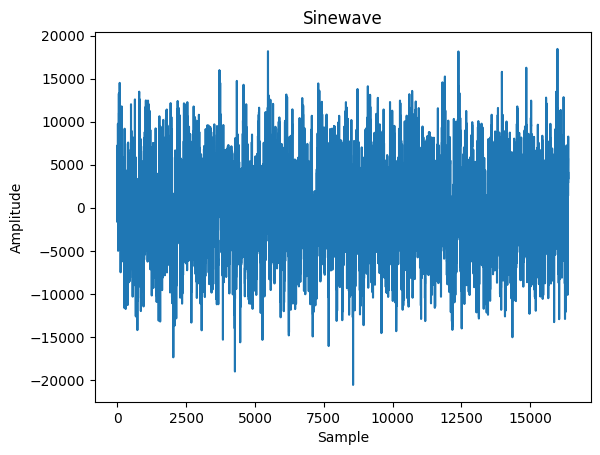

In [4]:
if has_hardware:
    pyAudioTest.globals['generate'] = 2 # Choose sinewave output for now
    time.sleep(2)
    pyAudioTest.waitCycle()
    data['sine_data'] = pyAudioTest.analyzeAudio(stream)
plt.plot(data['sine_data']['data'][0])
plt.title('Sinewave')
plt.xlabel('Sample')
plt.ylabel('Amplitude')

Now switch to the tone cluster waveform. This is what we'll be using for the frequency response test. Again, adjust the volume control until the overall amplitude is below 32000 units.

Text(0.5, 1.0, 'Tone cluster waveform')

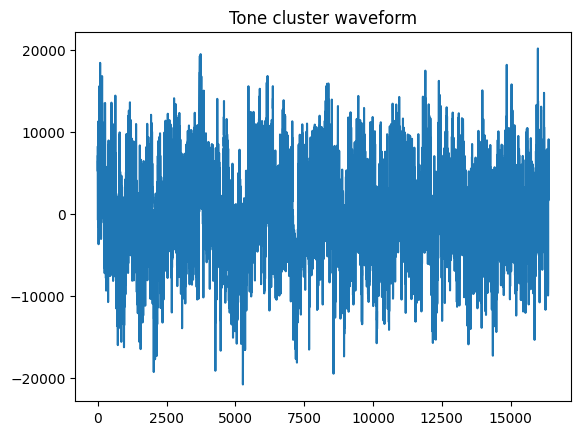

In [5]:
if has_hardware:
    pyAudioTest.globals['generate'] = 1 # the tone cluster waveform
    time.sleep(2)
    pyAudioTest.waitCycle()
    data['tone_cluster_data'] = pyAudioTest.analyzeAudio(stream)
    data['tone_index'] = pyAudioTest.toneIndex
plt.plot(data['tone_cluster_data']['data'][0])
plt.title('Tone cluster waveform')

Before we continue, let's see what this waveform actually produces in frequency space. It's a bunch of discrete peaks, all of which are 1 unit wide. In subsequent graphs, I will only show the tips of the peaks. The rest is noise.

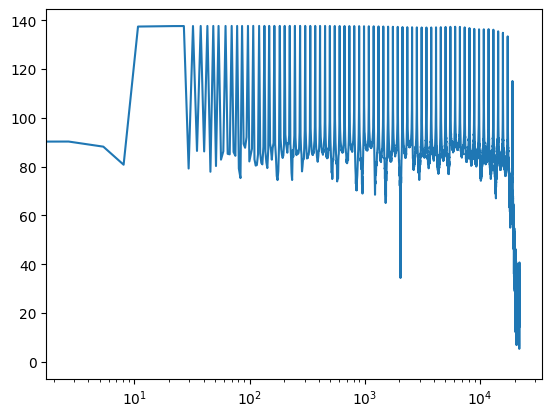

In [6]:
plt.semilogx(pyAudioTest.frequencyScale, data['tone_cluster_data']['dbfft'][0])

Here's a plot of just the tones in the tone cluster waveform. Some things are immediately noticeable. First, the response curve looks quite smooth. That's good. It means the analyzer produces a good display from a single block of data with no averaging needed. Second, the curve looks wiggly at high frequencies, but the wiggles are all within 1/2 dB of a response curve that you'd expect if the 3 dB point is at 20 kHz. The audio adapter is performing well.

Text(0, 0.5, 'Amplitude (dB)')

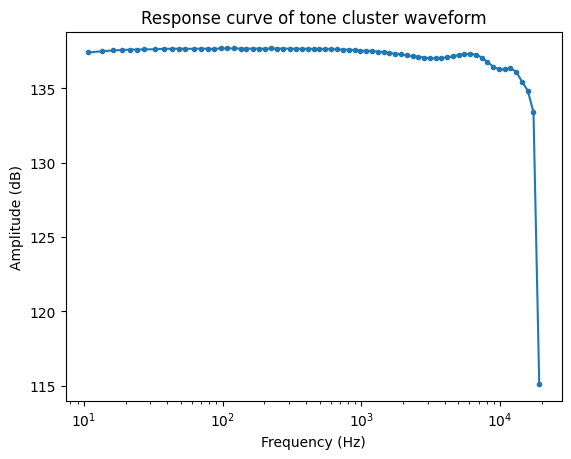

In [7]:
plt.semilogx(pyAudioTest.toneFrequency, data['tone_cluster_data']['dbfft'][0][data['tone_index']], marker = '.')
plt.title('Response curve of tone cluster waveform')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude (dB)')

# On with the testing

Now I've changed my test setup. I ran patch cables from Line Out of the audio adapter to the input of the HPF-Pre, and from the output of the HPF-Pre to Line In. The HPF has only one knob, for the cutoff frequency of the filter. I will try 3 knob settings.

First I will measure and record a "baseline" which is the response of the patch cord. This defines a 0 dB level at each frequency.

In [8]:
if has_hardware:
    pyAudioTest.waitCycle() # make sure one "cycle" of data have been collected
    data['baseline'] = pyAudioTest.analyzeAudio(stream)['dbfft'][0]

Next, I will define a function for the response curve, for convenience, 

In [9]:
def response():
    pyAudioTest.waitCycle() # make sure one "cycle" of data have been collected
    d = pyAudioTest.analyzeAudio(stream)
    return (d['dbfft'][0] - data['baseline'])[pyAudioTest.toneIndex]

if has_hardware:
    data['fc_open'] = response()

In [10]:
if has_hardware:
    data['fc_hi'] = response()

In [11]:
if has_hardware:
    data['fc_lo'] = response()

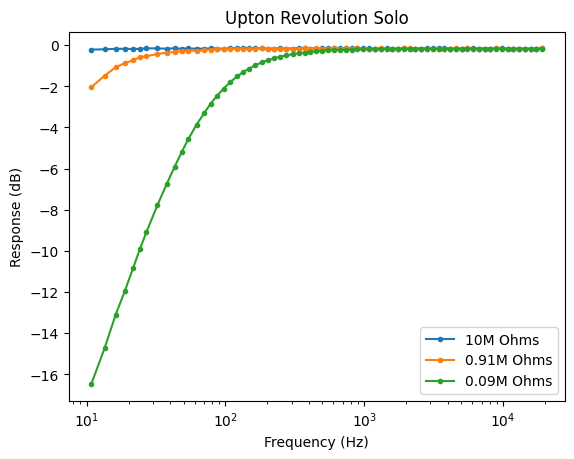

In [12]:
plt.semilogx(pyAudioTest.toneFrequency, data['fc_open'], marker = '.', label = '10M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['fc_hi'], marker = '.', label = '0.91M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['fc_lo'], marker = '.', label = '0.09M Ohms')
plt.title('Upton Revolution Solo')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Response (dB)')
plt.legend()
plt.show()

In [13]:
data.write_to(data_filename)

In [14]:
if has_hardware:
    data['und_open'] = response()

In [15]:
if has_hardware:
    data['und_hi'] = response()

In [16]:
if has_hardware:
    data['und_lo'] = response()

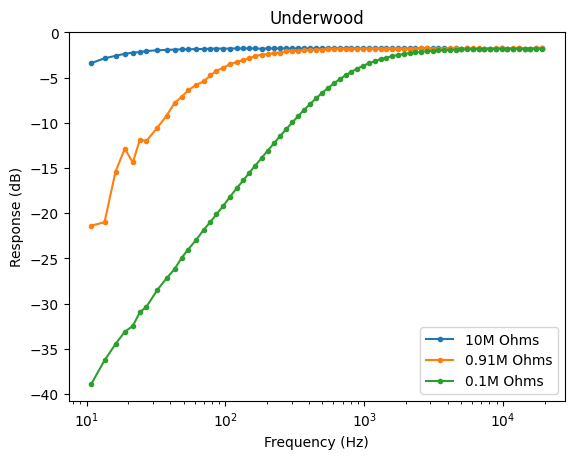

In [17]:
plt.semilogx(pyAudioTest.toneFrequency, data['und_open'], marker = '.', label = '10M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['und_hi'], marker = '.', label = '0.91M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['und_lo'], marker = '.', label = '0.1M Ohms')
plt.title('Underwood')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Response (dB)')
plt.legend()
plt.show()

In [18]:
data.write_to(data_filename)

In [19]:
if has_hardware:
    data['bassmax_open'] = response()

In [20]:
if has_hardware:
    data['bassmax_hi'] = response()

In [21]:
if has_hardware:
    data['bassmax_lo'] = response()

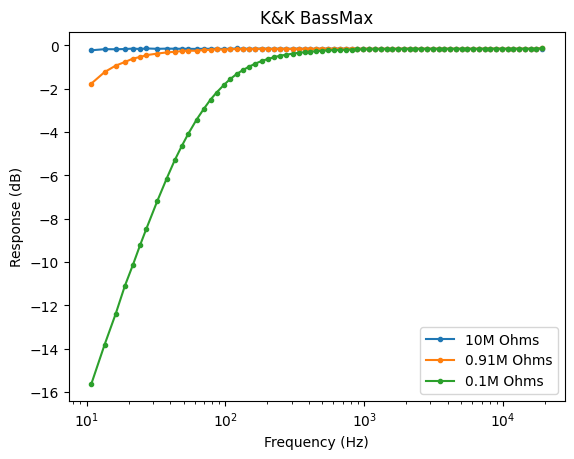

In [22]:
plt.semilogx(pyAudioTest.toneFrequency, data['bassmax_open'], marker = '.', label = '10M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['bassmax_hi'], marker = '.', label = '0.91M Ohms')
plt.semilogx(pyAudioTest.toneFrequency, data['bassmax_lo'], marker = '.', label = '0.1M Ohms')
plt.title('K&K BassMax')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Response (dB)')
plt.legend()
plt.show()

In [23]:
data.write_to(data_filename)

In [33]:
!jupyter nbconvert --to pdf Piezo_pickup_testing.ipynb

[NbConvertApp] Converting notebook Piezo_pickup_testing.ipynb to pdf
[NbConvertApp] Support files will be in Piezo_pickup_testing_files/
[NbConvertApp] Making directory ./Piezo_pickup_testing_files
[NbConvertApp] Writing 51391 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 269028 bytes to Piezo_pickup_testing.pdf
